# 01 - Análise Exploratória de Dados (EDA)

Este notebook realiza a análise exploratória da base de obesidade (`data/obesity.csv`), com foco na inspeção inicial dos dados, tratamento dos ruídos decimais indicados no dicionário e visualizações sobre a relação entre hábitos comportamentais e níveis de obesidade.

## 1. Importação das bibliotecas

Nesta etapa, carregamos as bibliotecas necessárias para manipulação dos dados e visualização gráfica.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

sns.set_theme(style='whitegrid', palette='Set2')

DATA_PATH = Path('../data/obesity.csv')
NOISY_COLUMNS = ['FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
TARGET_CANDIDATES = ['Obesity_level', 'Obesity']

## 2. Carga e inspeção inicial

A base é carregada a partir do caminho `../data/obesity.csv`. Em seguida, avaliamos dimensões, primeiras linhas, tipos das colunas e estatísticas descritivas.

In [2]:
def load_dataset(path: Path) -> pd.DataFrame:
    """Carrega o arquivo CSV da base de obesidade."""
    if not path.exists():
        raise FileNotFoundError(f'Arquivo não encontrado: {path}')

    return pd.read_csv(path)


df_raw = load_dataset(DATA_PATH)

print(f'Dimensões da base: {df_raw.shape[0]} linhas x {df_raw.shape[1]} colunas')
display(df_raw.head())

Dimensões da base: 2111 linhas x 17 colunas


,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [3]:
print('Informações gerais da base:')
df_raw.info()

Informações gerais da base:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2111 non-null   object 
 1   Age             2111 non-null   float64
 2   Height          2111 non-null   float64
 3   Weight          2111 non-null   float64
 4   family_history  2111 non-null   object 
 5   FAVC            2111 non-null   object 
 6   FCVC            2111 non-null   float64
 7   NCP             2111 non-null   float64
 8   CAEC            2111 non-null   object 
 9   SMOKE           2111 non-null   object 
 10  CH2O            2111 non-null   float64
 11  SCC             2111 non-null   object 
 12  FAF             2111 non-null   float64
 13  TUE             2111 non-null   float64
 14  CALC            2111 non-null   object 
 15  MTRANS          2111 non-null   object 
 16  Obesity         2111 non-null   object 
dtypes: fl

In [4]:
print('Estatísticas descritivas das variáveis numéricas:')
display(df_raw.describe())

print('Estatísticas descritivas das variáveis categóricas:')
display(df_raw.describe(include='object'))

Estatísticas descritivas das variáveis numéricas:


,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


Estatísticas descritivas das variáveis categóricas:


,Gender,family_history,FAVC,CAEC,SMOKE,SCC,CALC,MTRANS,Obesity
count,2111,2111,2111,2111,2111,2111,2111,2111,2111
unique,2,2,2,4,2,2,4,5,7
top,Male,yes,yes,Sometimes,no,no,Sometimes,Public_Transportation,Obesity_Type_I
freq,1068,1726,1866,1765,2067,2015,1401,1580,351


## 3. Qualidade dos dados

Antes das visualizações, verificamos valores nulos e registros duplicados para entender possíveis problemas de qualidade.

In [5]:
missing_report = df_raw.isna().sum().to_frame('missing_count')
missing_report['missing_percentage'] = missing_report['missing_count'] / len(df_raw) * 100

display(missing_report.sort_values('missing_count', ascending=False))

duplicated_count = df_raw.duplicated().sum()
print(f'Registros duplicados: {duplicated_count}')
print(f'Percentual de duplicados: {duplicated_count / len(df_raw) * 100:.2f}%')

,missing_count,missing_percentage
Gender,0,0.0
Age,0,0.0
Height,0,0.0
Weight,0,0.0
family_history,0,0.0
FAVC,0,0.0
FCVC,0,0.0
NCP,0,0.0
CAEC,0,0.0
SMOKE,0,0.0


Registros duplicados: 24
Percentual de duplicados: 1.14%


## 4. Tratamento dos ruídos decimais

Conforme o dicionário de dados, as colunas `FCVC`, `NCP`, `CH2O`, `FAF` e `TUE` possuem valores decimais que representam ruídos. Por isso, esses campos são arredondados para o inteiro mais próximo antes das análises.

In [6]:
def round_noisy_columns(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    """Arredonda colunas com ruídos decimais para o inteiro mais próximo."""
    df = df.copy()

    missing_columns = [col for col in columns if col not in df.columns]
    if missing_columns:
        raise ValueError(f'Colunas não encontradas na base: {missing_columns}')

    for col in columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').round().astype('Int64')

    return df


df = round_noisy_columns(df_raw, NOISY_COLUMNS)

print('Amostra das colunas após arredondamento:')
display(df[NOISY_COLUMNS].head())

Amostra das colunas após arredondamento:


,FCVC,NCP,CH2O,FAF,TUE
0,2,3,2,0,1
1,3,3,3,3,0
2,2,3,2,2,1
3,3,3,2,2,0
4,2,1,2,0,0


In [7]:
print('Distribuição das colunas arredondadas:')
for col in NOISY_COLUMNS:
    display(df[col].value_counts(dropna=False).sort_index().to_frame(name='count'))

Distribuição das colunas arredondadas:


,count
FCVC,
1,102
2,1013
3,996


,count
NCP,
1,316
2,176
3,1470
4,149


,count
CH2O,
1,485
2,1110
3,516


,count
FAF,
0,720
1,776
2,496
3,119


,count
TUE,
0,952
1,915
2,244


## 5. Identificação da variável alvo

A base pode conter a variável alvo com o nome `Obesity_level` ou `Obesity`. A célula abaixo identifica automaticamente qual dessas colunas está disponível.

In [8]:
def identify_target_column(df: pd.DataFrame, candidates: list[str]) -> str:
    """Identifica a coluna alvo entre os nomes possíveis."""
    for col in candidates:
        if col in df.columns:
            return col

    raise ValueError(f'Nenhuma coluna alvo encontrada. Opções esperadas: {candidates}')


target_col = identify_target_column(df, TARGET_CANDIDATES)
print(f'Coluna alvo identificada: {target_col}')

Coluna alvo identificada: Obesity


## 6. Distribuição da variável alvo

A distribuição da variável alvo permite avaliar se existe desbalanceamento entre as classes de obesidade.

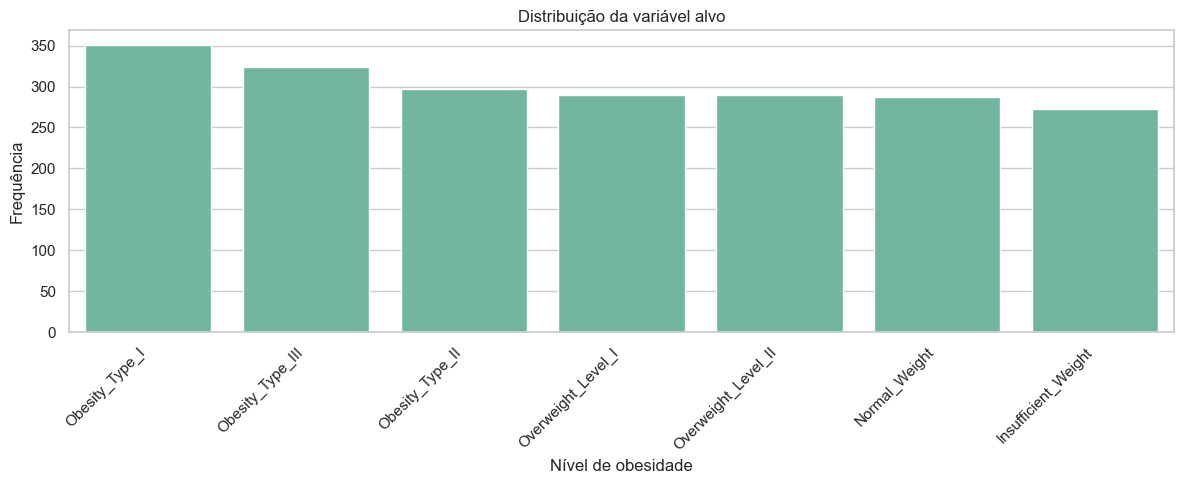

,percentage
Obesity,
Obesity_Type_I,16.63
Obesity_Type_III,15.35
Obesity_Type_II,14.07
Overweight_Level_I,13.74
Overweight_Level_II,13.74
Normal_Weight,13.60
Insufficient_Weight,12.88


In [9]:
target_order = df[target_col].value_counts().index

plt.figure(figsize=(12, 5))
sns.countplot(data=df, x=target_col, order=target_order)
plt.title('Distribuição da variável alvo')
plt.xlabel('Nível de obesidade')
plt.ylabel('Frequência')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

target_distribution = df[target_col].value_counts(normalize=True).mul(100).round(2).to_frame('percentage')
display(target_distribution)

## 7. Relação entre peso e altura

A relação entre `Weight` e `Height` ajuda a visualizar a separação das classes de obesidade no espaço antropométrico.

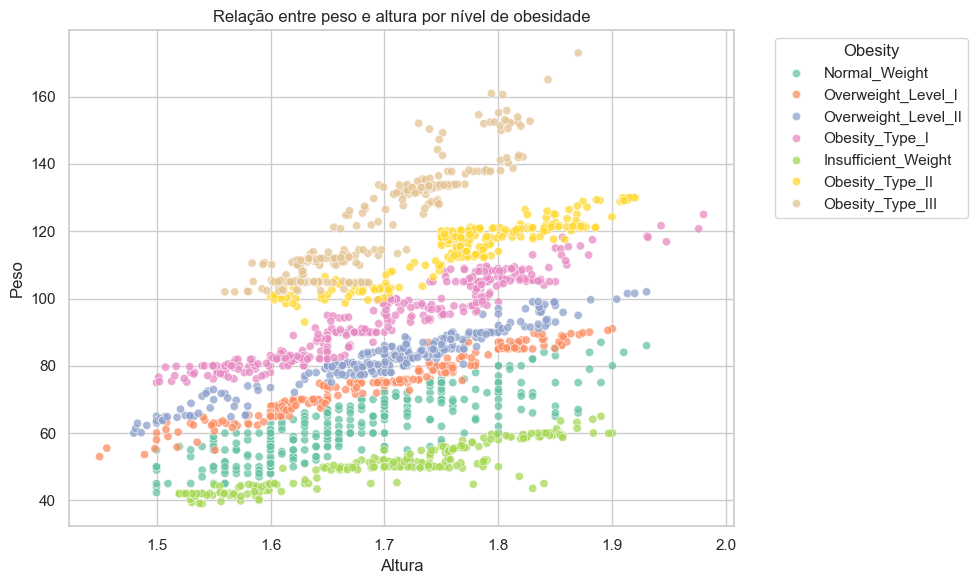

In [10]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='Height',
    y='Weight',
    hue=target_col,
    alpha=0.75
)
plt.title('Relação entre peso e altura por nível de obesidade')
plt.xlabel('Altura')
plt.ylabel('Peso')
plt.legend(title=target_col, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 8. Hábitos comportamentais vs. obesidade

Nesta etapa, avaliamos a relação entre o nível de obesidade e três variáveis comportamentais relevantes: histórico familiar, consumo frequente de alimentos calóricos e atividade física.

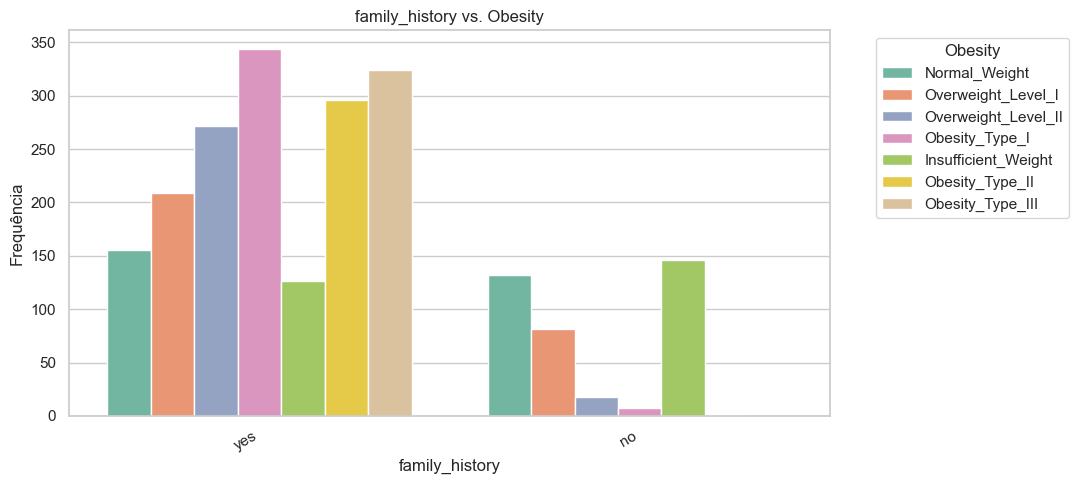

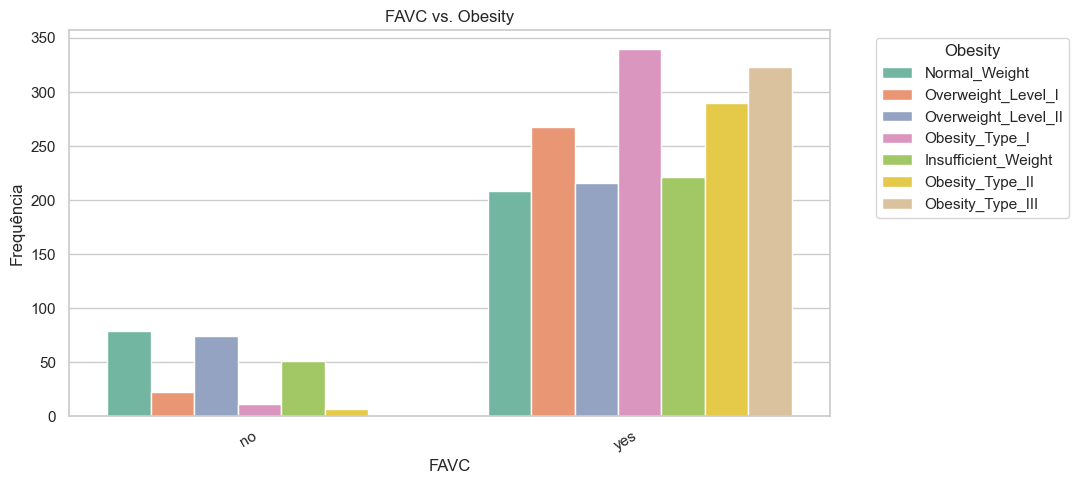

In [11]:
def plot_categorical_vs_target(df: pd.DataFrame, feature: str, target: str) -> None:
    """Plota a distribuição de uma variável categórica cruzada com a variável alvo."""
    plt.figure(figsize=(11, 5))
    sns.countplot(data=df, x=feature, hue=target)
    plt.title(f'{feature} vs. {target}')
    plt.xlabel(feature)
    plt.ylabel('Frequência')
    plt.xticks(rotation=30, ha='right')
    plt.legend(title=target, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


for feature in ['family_history', 'FAVC']:
    if feature in df.columns:
        plot_categorical_vs_target(df, feature, target_col)
    else:
        print(f'Coluna não encontrada: {feature}')

### 8.1 Atividade física vs. obesidade

A variável `FAF` representa frequência de atividade física. Após o arredondamento, ela é tratada como uma escala discreta para comparação entre classes de obesidade.

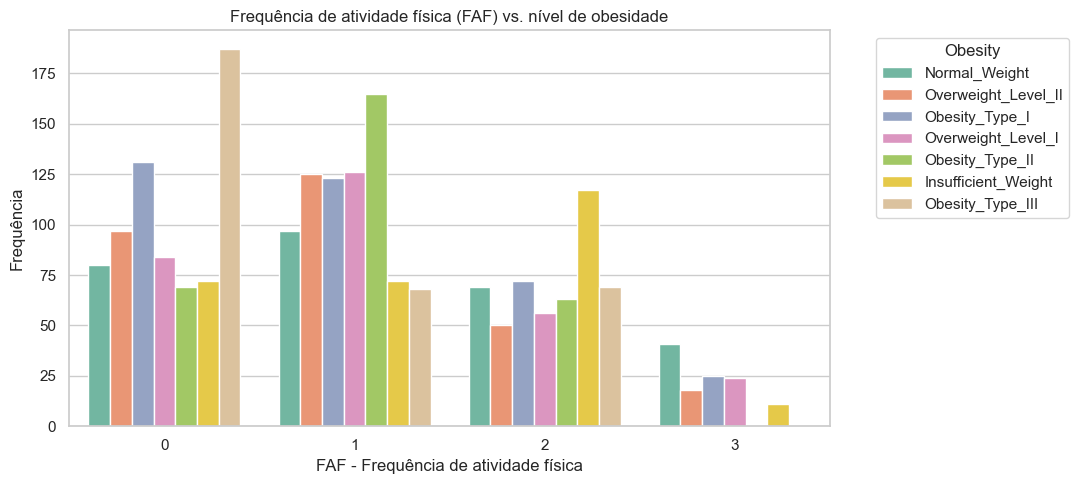

In [12]:
if 'FAF' in df.columns:
    plt.figure(figsize=(11, 5))
    sns.countplot(data=df, x='FAF', hue=target_col)
    plt.title('Frequência de atividade física (FAF) vs. nível de obesidade')
    plt.xlabel('FAF - Frequência de atividade física')
    plt.ylabel('Frequência')
    plt.legend(title=target_col, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print('Coluna FAF não encontrada.')

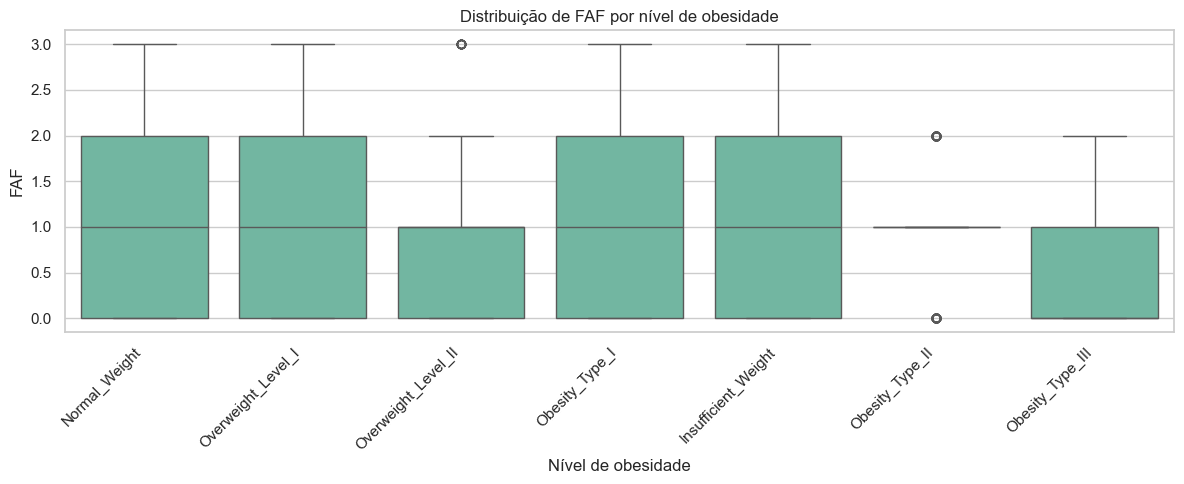

In [13]:
if 'FAF' in df.columns:
    plt.figure(figsize=(12, 5))
    sns.boxplot(data=df, x=target_col, y='FAF')
    plt.title('Distribuição de FAF por nível de obesidade')
    plt.xlabel('Nível de obesidade')
    plt.ylabel('FAF')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## 9. Tabelas cruzadas proporcionais

As tabelas abaixo mostram a proporção de classes de obesidade dentro de cada categoria dos hábitos analisados, facilitando a comparação relativa entre grupos.

In [14]:
behavior_features = ['family_history', 'FAVC', 'FAF']

for feature in behavior_features:
    if feature in df.columns:
        crosstab_pct = pd.crosstab(df[feature], df[target_col], normalize='index').mul(100).round(2)
        print(f'Proporção de {target_col} por {feature}:')
        display(crosstab_pct)

Proporção de Obesity por family_history:


Obesity,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
family_history,,,,,,,
no,37.92,34.29,1.82,0.26,0.00,21.04,4.68
yes,7.30,8.98,19.93,17.15,18.77,12.11,15.76


Proporção de Obesity por FAVC:


Obesity,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
FAVC,,,,,,,
no,20.82,32.24,4.49,2.86,0.41,8.98,30.20
yes,11.84,11.15,18.22,15.54,17.31,14.36,11.58


Proporção de Obesity por FAF:


Obesity,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
FAF,,,,,,,
0,10.00,11.11,18.19,9.58,25.97,11.67,13.47
1,9.28,12.50,15.85,21.26,8.76,16.24,16.11
2,23.59,13.91,14.52,12.70,13.91,11.29,10.08
3,9.24,34.45,21.01,0.00,0.00,20.17,15.13


## 10. Conclusões iniciais

Este notebook entrega uma primeira visão da base de obesidade, com tratamento dos ruídos decimais antes das análises visuais. As próximas etapas recomendadas são: aprofundar a análise estatística, realizar codificação das variáveis categóricas, separar treino e teste de forma estratificada e treinar modelos supervisionados para classificação do nível de obesidade.